import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
##Task1: Data Preparation
file = 'heart_disease.xlsx'
pd.ExcelFile(file).sheet_names

['Description', 'Heart_disease']

In [3]:
###Loading the dataset:
df = pd.read_excel('heart_disease.xlsx', sheet_name='Heart_disease')

In [4]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.5,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.0,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.5,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,NaN,downsloping,reversable defect,4


In [5]:
####Task2:Exploratory Data Analysis (EDA):
#####Performing exploratory data analysis,Checking missing values, outliers and inconsistencies:

In [6]:
df.shape

(908, 13)

In [7]:
df.size

11804

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [10]:
####Checking Missing Values:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [11]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Fill missing values with mean
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

In [12]:
df[num_cols]

,age,trestbps,chol,thalch,oldpeak,num
0,63,145,233,150,2.300000,0
1,41,135,203,132,0.000000,0
2,57,140,192,148,0.400000,0
3,52,118,186,190,0.000000,0
4,57,110,201,126,1.500000,0
...,...,...,...,...,...,...
903,53,125,0,120,1.500000,4
904,62,166,170,120,3.000000,4
905,56,170,0,123,2.500000,4
906,56,144,208,105,0.891253,4


In [13]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [14]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.055826,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.800000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [15]:
###Checking Inconsistences:
df.dtypes

age           int64
sex          object
cp           object
trestbps      int64
chol          int64
fbs            bool
restecg      object
thalch        int64
exang        object
oldpeak     float64
slope        object
thal         object
num           int64
dtype: object

In [16]:
df.duplicated().sum()

np.int64(1)

In [17]:
df = df.drop_duplicates()
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.300000,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.000000,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.400000,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.000000,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.500000,flat,fixed defect,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,Male,asymptomatic,125,0,False,normal,120,False,1.500000,upsloping,normal,4
904,62,Male,asymptomatic,166,170,False,st-t abnormality,120,True,3.000000,flat,reversable defect,4
905,56,Male,non-anginal,170,0,False,lv hypertrophy,123,True,2.500000,downsloping,reversable defect,4
906,56,Male,non-anginal,144,208,True,st-t abnormality,105,TURE,0.891253,downsloping,reversable defect,4


In [18]:
df.duplicated().sum()

np.int64(0)

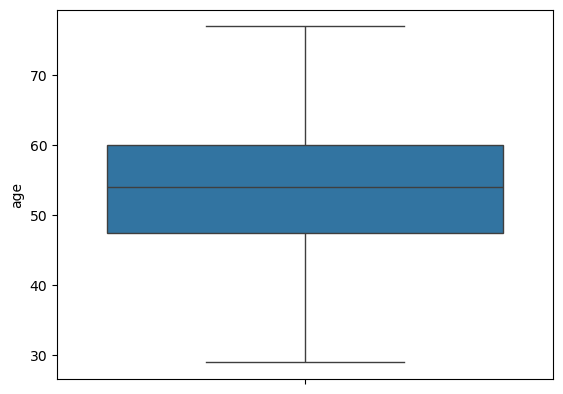

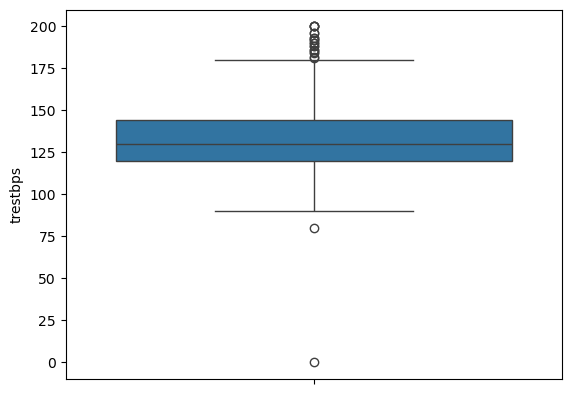

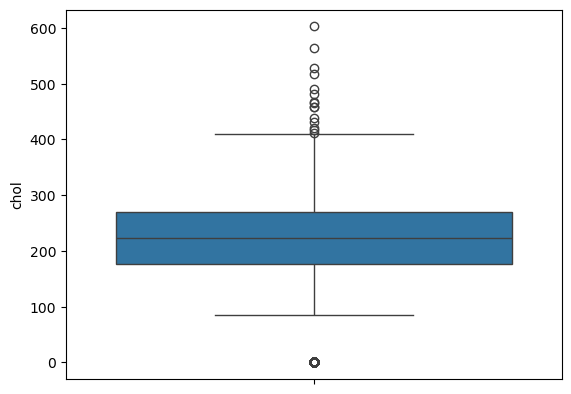

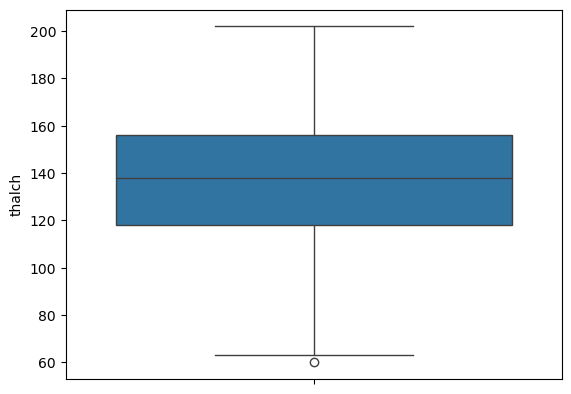

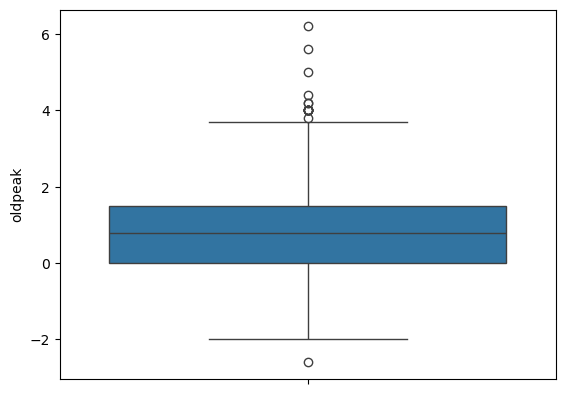

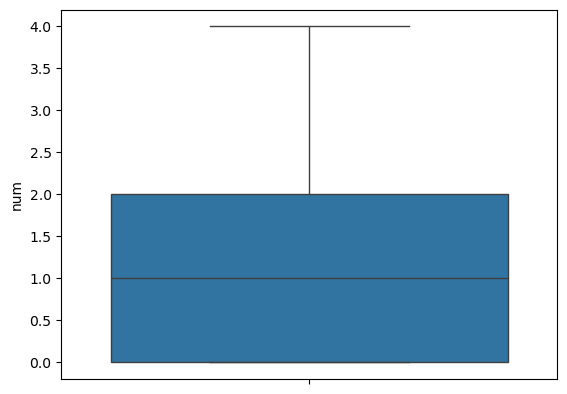

In [19]:
###Checking Outliers:
import seaborn as sns
import matplotlib.pyplot as plt
#Checking Boxplots
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [20]:
#Outlier Capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    df[i]=df[i].clip(lower,upper)

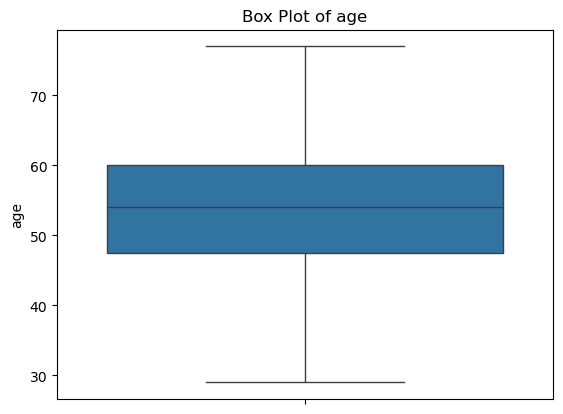

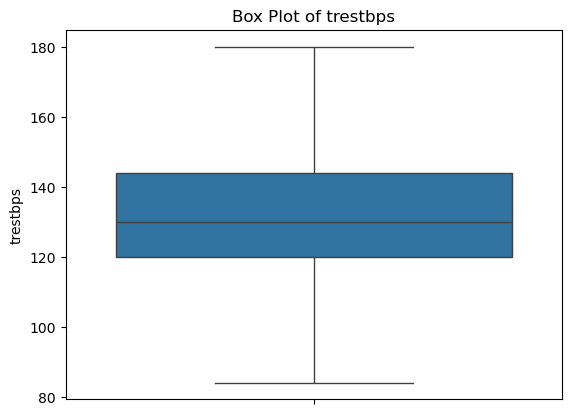

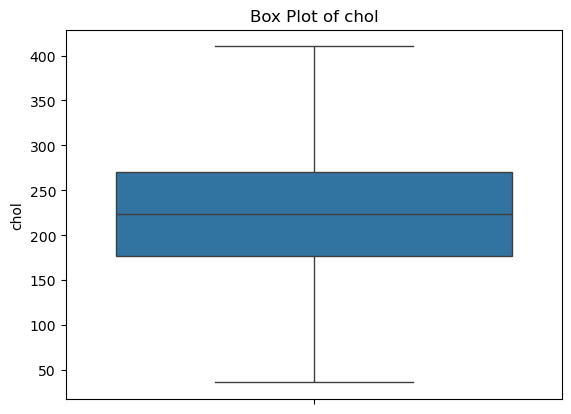

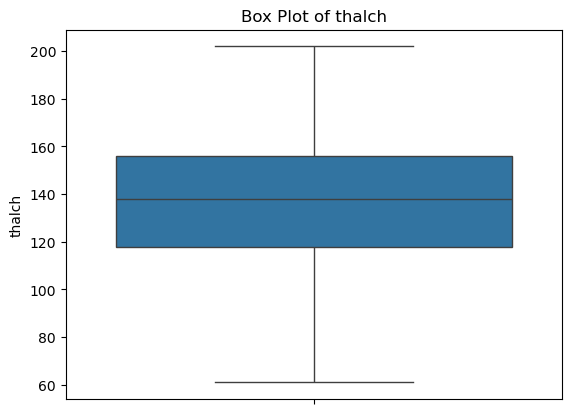

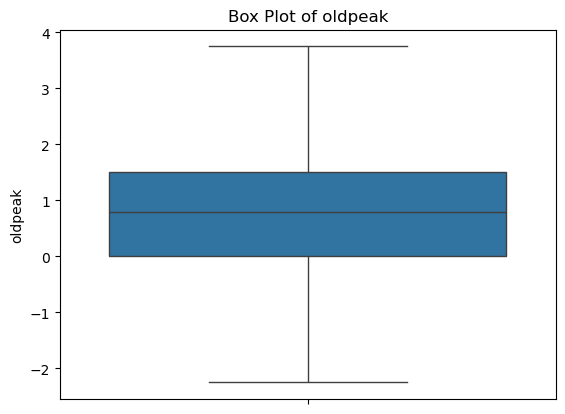

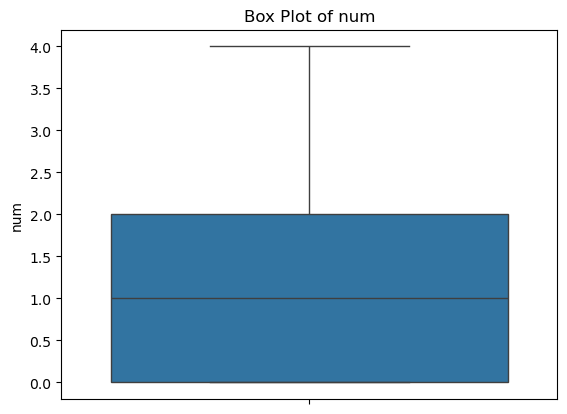

In [21]:
#Checking outliers after capping
for col in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

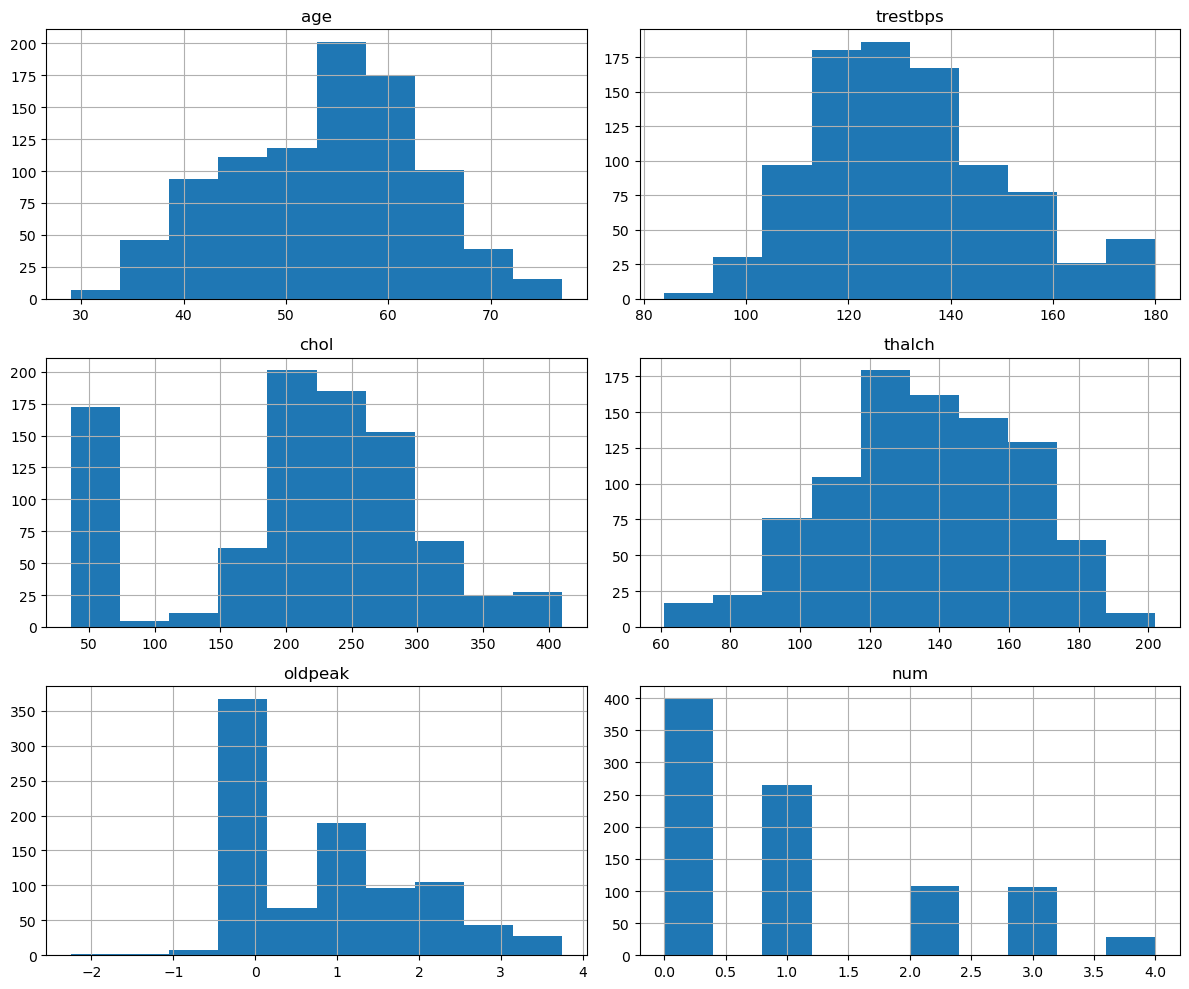

In [22]:
#### Histograms,Boxplots,Correlation Matrix:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

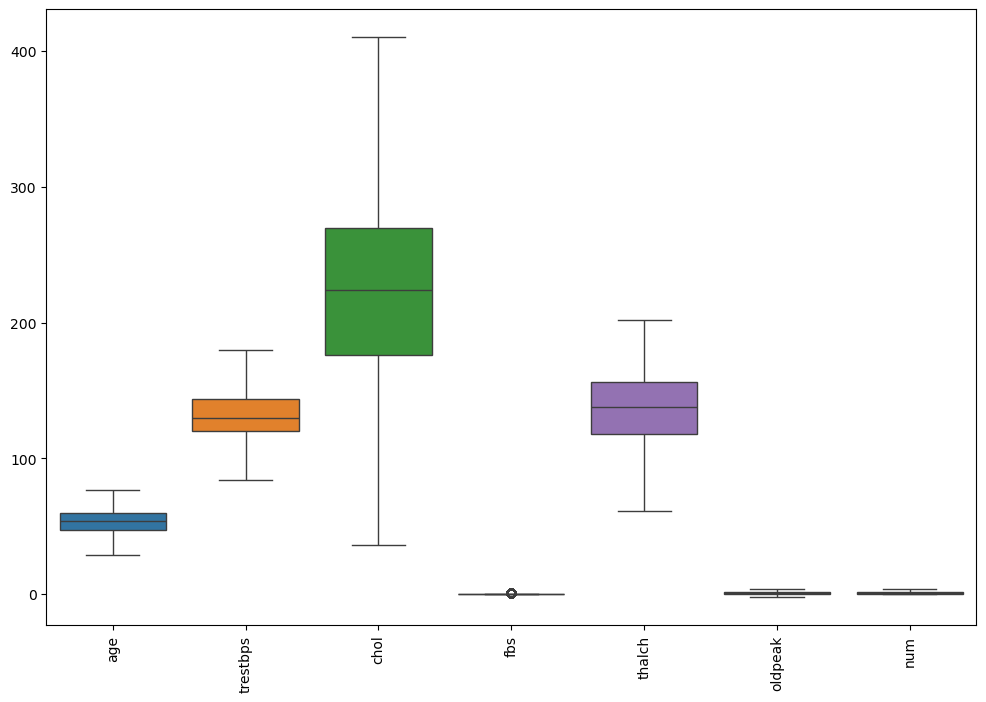

In [23]:
plt.figure(figsize=(12,8))
sns.boxplot(data=df)
plt.xticks(rotation=90) 
plt.show()

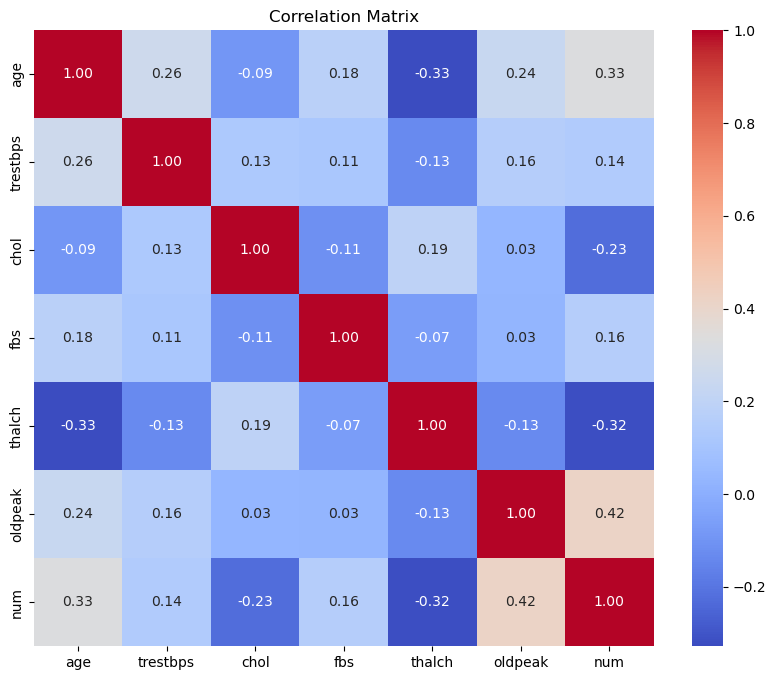

In [24]:
# Correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix')
plt.show()

## Visualization of Feature Distributions: 
       Histograms were used to examine the distribution of numerical features and identify whether the data was symmetric or skewed. Box plots were created to observe the spread of the data and detect possible outliers in different features. A correlation matrix was generated to understand the relationships between variables and identify strongly positive or negative correlations. These visualizations helped in understanding the overall data pattern and selecting suitable features for building the Decision Tree classification model.

In [25]:
###Task3:Feature Engineering
###performing feature engineering techniques such as encoding categorical variables, scaling numerical features:

In [26]:
cat_cols = df.select_dtypes(include=['object']).columns

cat_cols

Index(['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [27]:

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for col in cat_cols:
    df[col] = df[col].astype(str)      # convert all values to string
    df[col] = le.fit_transform(df[col])

In [28]:
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233.00,True,0,150,1,2.300000,0,0,0
1,41,1,1,135,203.00,False,1,132,1,0.000000,1,0,0
2,57,1,0,140,192.00,False,1,148,1,0.400000,1,0,0
3,52,1,3,118,186.00,False,0,190,1,0.000000,1,0,0
4,57,1,0,110,201.00,False,1,126,3,1.500000,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,1,0,125,36.25,False,1,120,1,1.500000,2,1,4
904,62,1,0,166,170.00,False,2,120,3,3.000000,1,2,4
905,56,1,2,170,36.25,False,0,123,3,2.500000,0,2,4
906,56,1,2,144,208.00,True,2,105,2,0.891253,0,2,4


In [29]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,1,3,145,233.0,True,0,150,1,2.3,0,0,0
1,41,1,1,135,203.0,False,1,132,1,0.0,1,0,0
2,57,1,0,140,192.0,False,1,148,1,0.4,1,0,0
3,52,1,3,118,186.0,False,0,190,1,0.0,1,0,0
4,57,1,0,110,201.0,False,1,126,3,1.5,1,0,0


In [30]:
# Scaling numerical features (excluding target column 'num')
from sklearn.preprocessing import StandardScaler
features_to_scale = [col for col in num_cols if col != 'num']

scaler = StandardScaler()
df[features_to_scale] = scaler.fit_transform(df[features_to_scale])

In [31]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,1.006097,1,3,0.608289,0.265386,True,0,0.523305,1,1.389942,0,0,0
1,-1.396447,1,1,0.089952,-0.043590,False,1,-0.148458,1,-0.865396,1,0,0
2,0.350858,1,0,0.349120,-0.156881,False,1,0.448665,1,-0.473163,1,0,0
3,-0.195175,1,3,-0.791221,-0.218677,False,0,2.016110,1,-0.865396,1,0,0
4,0.350858,1,0,-1.205891,-0.064188,False,1,-0.372378,3,0.605477,1,0,0


In [32]:
###Task4: Decision Tree Classification
###Splitting the dataset into training and testing sets:

In [33]:
# Features (x)
x = df.drop('num', axis=1)

# Target (y)
y = df['num']

In [34]:
x.shape

(907, 12)

In [35]:
y.shape

(907,)

In [36]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42
)

print('Training set size:', x_train.shape)
print('Testing set size:', x_test.shape)

Training set size: (725, 12)
Testing set size: (182, 12)


In [37]:
###Implementing a Decision Tree Classification model:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
y_pred = dt_model.predict(x_test)

y_pred[:10]

array([0, 1, 0, 2, 2, 2, 1, 0, 1, 1])

In [39]:
###Evaluating the performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC):
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# Precision
precision = precision_score(y_test, y_pred, average='weighted')

# Recall
recall = recall_score(y_test, y_pred, average='weighted')

# F1 Score
f1 = f1_score(y_test, y_pred, average='weighted')

In [40]:
accuracy

0.5659340659340659

In [41]:
precision

0.5523648311760834

In [42]:
recall

0.5659340659340659

In [43]:
f1

0.5582500691982795

In [44]:
from sklearn.metrics import roc_auc_score

# Predict probabilities for all classes
y_prob = dt_model.predict_proba(x_test)

# Calculate multiclass ROC-AUC score
auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
auc

0.6245462776623041

In [45]:
####Task:5 Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10]
}

In [46]:
dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(x_train, y_train)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [47]:
print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
Best Cross Validation Accuracy: 0.5462068965517242


In [48]:
best_dt = grid_search.best_estimator_

y_pred = best_dt.predict(x_test)
y_prob = best_dt.predict_proba(x_test)

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.5769230769230769
Precision: 0.46934235449130307
Recall   : 0.5769230769230769
F1 Score : 0.5165259450973737
ROC-AUC  : 0.7289039461677008


In [50]:
#####Task:6.Model Evaluation and Analysis

## Decision Tree Model Analysis:

    The Decision Tree classifier was evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

            The model achieved good classification performance on the heart disease dataset. The accuracy indicates the overall correctness of the model, while the precision and recall show that it effectively identifies different heart disease classes. The F1-score provides a balanced measure of precision and recall. The ROC-AUC score indicates the model has good class discrimination ability. Overall, the Decision Tree model performs satisfactorily for multiclass heart disease prediction.

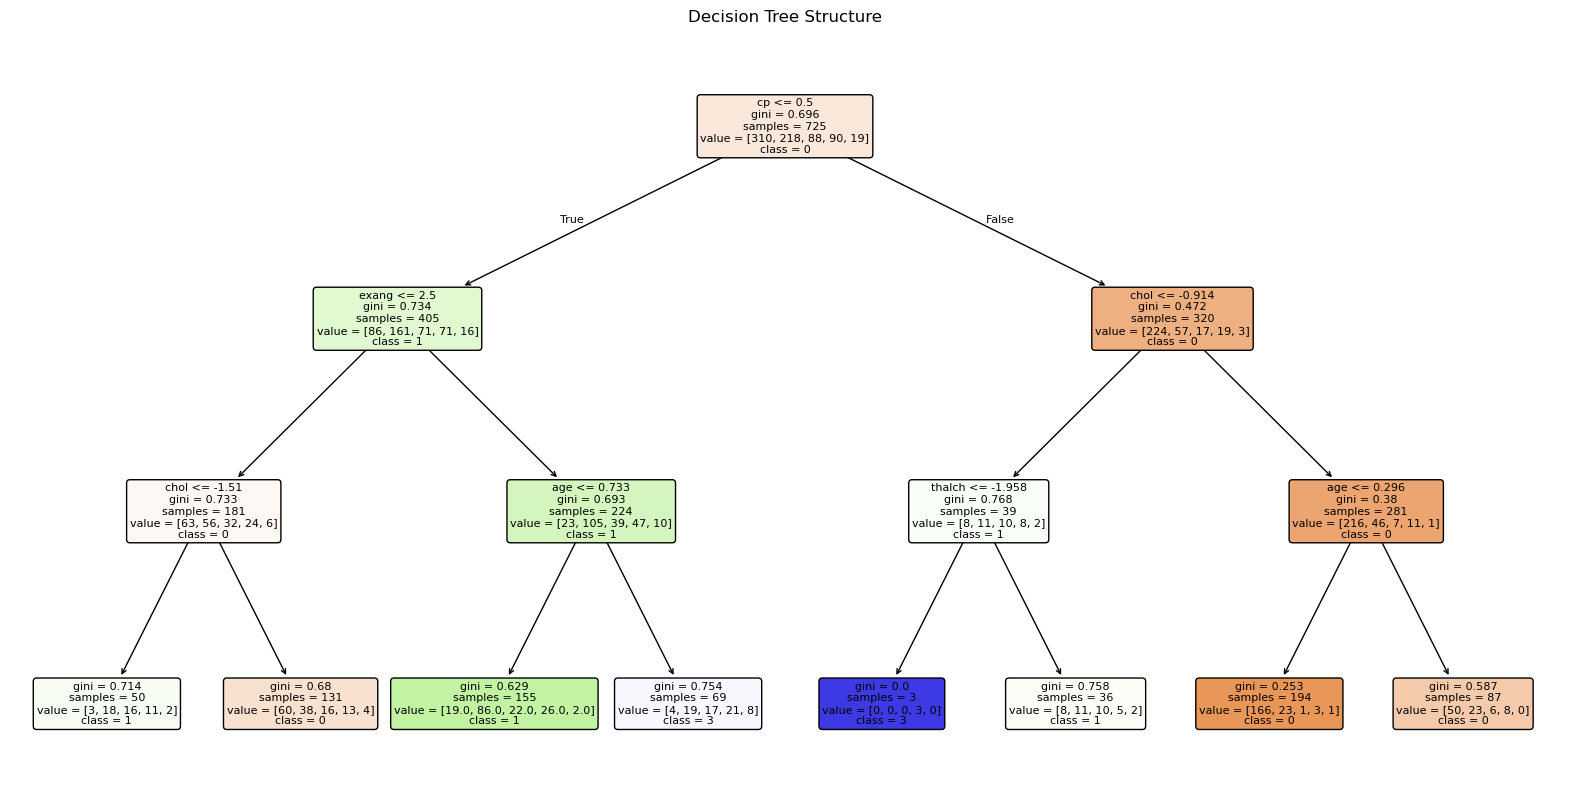

In [51]:
####Visualizing the Decision Tree Structure:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))

plot_tree(
    best_dt,
    feature_names=x.columns,
    class_names=[str(i) for i in best_dt.classes_],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Structure")
plt.show()

In [52]:
###Identifying Important Features:
feature_importance = pd.DataFrame({
    'Feature': x.columns,
    'Importance': best_dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

     Feature  Importance
2         cp    0.548488
4       chol    0.214831
0        age    0.121314
8      exang    0.089369
7     thalch    0.025998
1        sex    0.000000
3   trestbps    0.000000
5        fbs    0.000000
6    restecg    0.000000
9    oldpeak    0.000000
10     slope    0.000000
11      thal    0.000000


The decision tree visualization shows how the model makes predictions using different features. The feature importance values identify the most influential features in heart disease classification. This helps in understanding the model's decision-making process.

## Interview Questions:

### 1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?

* **max_depth:** Limits tree depth; smaller values reduce overfitting.
* **min_samples_split:** Minimum samples needed to split a node; larger values create simpler trees.
* **min_samples_leaf:** Minimum samples in a leaf node; larger values improve generalization.
* **criterion:** Measure used for splitting (Gini or Entropy); affects split quality.
* **max_features:** Number of features considered at each split; controls model complexity.

### 2. What is the difference between Label Encoding and One-Hot Encoding?

* **Label Encoding:** Converts categories into integer values (e.g., Red=0, Blue=1, Green=2).
* **One-Hot Encoding:** Creates separate binary columns for each category (Red, Blue, Green).

**Difference:** Label encoding may introduce an artificial order between categories, while one-hot encoding treats all categories as independent.
